# otwin 08 · Does the physics earn its place?

**Question.** Notebook 07 put a 90 % band around the plainest possible forecast — a straight line
— and it covered. Would a fade law with real structure narrow that band? Would a learned
residual on top of it? This is the hybrid-twin hypothesis, on field data, with a criterion set
before looking.

**What otwin does here.** The same leakage-free protocol, the same conformal construction, the
same measurement. It does not supply any of the laws or the learner — that is the point: the
library is the test bench, and the models are what is on trial.

**What you write yourself.** Five fade laws, one residual learner, and the one control that
makes the comparison fair.

**What you will learn**

1. how to set a pass/fail criterion for a model *before* the data can flatter it
2. why a "physical" parameter the data cannot identify extrapolates worse than a line
3. the confound that makes a hybrid look better than it is, and the control that removes it
4. how to read a result that is inside its own uncertainty — and still call it a result

*Real data (same Source Data file as notebook 07). Runtime ≈ 2 min. Opens in Colab.*


## Setup

Install, style, data — as in notebook 07. `MODE` is printed.

In [1]:
!pip install -q otwin openpyxl 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])
from packaging.version import Version
assert Version(otwin.__version__) >= Version("0.3.0")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.4/180.4 kB 4.7 MB/s eta 0:00:00
otwin 0.3.1 | python 3.13.15


In [2]:
import os, json, warnings, itertools
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
TEAL, RED, SLATE, GRID, OBS, AMBER = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black", "#B7791F"
MODEL_COLOR = {"L  linear fleet rate (nb 07)": SLATE, "C  calendar only": AMBER, "E  cycle only": "#7C3AED", "P  calendar + cycle": TEAL,
               "M  MATR two-term in EFC": "#2B6CB0", "H  M + learned residual": RED}
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","font.family":"DejaVu Sans",
    "axes.titlesize":13,"axes.labelsize":11,"axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,
    "axes.axisbelow":True,"figure.dpi":110,"savefig.dpi":200})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
def save(fig, name):
    p=os.path.join(FIGDIR, name+".png"); fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p)
def put(ax, text):
    if MODE == "DEMO":
        ax.text(0.5, 0.5, "DEMO DATA", transform=ax.transAxes, ha="center", va="center", fontsize=26, color=RED, alpha=0.2, rotation=20)
    ax.set_title(text)


In [3]:
# Data: Source Data of Fig. 2, sheet 'a)-c)'. Columns Time, ID, Chemistry, Capacity_Ah, Energy_kWh, Age_a, EFC_count.
import urllib.request
URL = "https://static-content.springer.com/esm/art%3A10.1038%2Fs41560-024-01620-9/MediaObjects/41560_2024_1620_MOESM4_ESM.xlsx"
CANDS = ["SourceData_Fig2.xlsx", "41560_2024_1620_MOESM4_ESM.xlsx", "data/SourceData_Fig2.xlsx"]
def _in_colab():
    try: import google.colab; return True
    except Exception: return False
PATH = next((p for p in CANDS if os.path.exists(p)), None); route = "(c) local file" if PATH else None
if PATH is None:
    try:
        urllib.request.urlretrieve(URL, CANDS[0])
        if os.path.getsize(CANDS[0]) > 2000: PATH, route = CANDS[0], "(a) downloaded"
    except Exception as e: print("download failed:", type(e).__name__)
if PATH is None and _in_colab():
    from google.colab import files; PATH = list(files.upload().keys())[0]; route = "(b) uploaded"
MODE = "REAL" if PATH else "DEMO"
print("route:", route, "| MODE:", MODE)

def load_tests(path):
    xl = pd.ExcelFile(path); sheet = next((s for s in xl.sheet_names if "a)" in s.lower()), xl.sheet_names[0])
    df = xl.parse(sheet); df.columns = [str(c).strip() for c in df.columns]
    t = pd.DataFrame({"system": df["ID"].astype(str), "chem": df["Chemistry"].astype(str).str.upper(),
                      "cap_Ah": pd.to_numeric(df["Capacity_Ah"], errors="coerce"),
                      "age_yr": pd.to_numeric(df["Age_a"], errors="coerce"),
                      "efc": pd.to_numeric(df["EFC_count"], errors="coerce")})
    t = t.dropna().sort_values(["system","age_yr"]).reset_index(drop=True)
    t["chem"] = t.chem.map(lambda s: "SLMO" if "LMO" in s else "MNMC" if "NMC" in s else "MLFP" if "LFP" in s else s)
    t["soh"] = t.cap_Ah / t.groupby("system").cap_Ah.transform("first")
    return t

def demo_tests(seed=0):
    rng = np.random.default_rng(seed); rows = []; k = 0
    for chem, n, a, b, efcy in (("SLMO",6,0.012,4.5e-5,250), ("MNMC",6,0.010,3.0e-5,200), ("MLFP",6,0.008,3.5e-5,200)):
        for _ in range(n):
            k += 1; aa, bb = a*rng.uniform(0.7,1.3), b*rng.uniform(0.6,1.4); ey = efcy*rng.uniform(0.6,1.4)
            ages = np.sort(np.r_[rng.uniform(0.4,1.5), rng.uniform(1.5, 7.5, rng.integers(1,4))])
            for t_ in ages:
                E = ey*t_*rng.uniform(0.95,1.05); cap = 13.5*(1 - aa*t_**0.6 - bb*E + rng.normal(0,0.012))
                rows.append(dict(system=f"ID_{k:02d}", chem=chem, cap_Ah=cap, age_yr=t_, efc=E))
    t = pd.DataFrame(rows).sort_values(["system","age_yr"]).reset_index(drop=True)
    t["soh"] = t.cap_Ah / t.groupby("system").cap_Ah.transform("first"); return t

tests = load_tests(PATH) if MODE == "REAL" else demo_tests()
assert tests.soh.between(0.4,1.3).all() and tests.age_yr.between(0,12).all()
print(tests.groupby("chem").agg(systems=("system","nunique"), tests=("soh","size"), efc_per_yr=("efc", lambda e: np.nan)).drop(columns="efc_per_yr"))
tests["efc_per_yr"] = tests.efc / tests.age_yr
print(f"\n{len(tests)} tests on {tests.system.nunique()} systems [{MODE}]; EFC/yr median by chemistry:")
print(tests.groupby("chem").efc_per_yr.median().round(0))


route: (a) downloaded | MODE: REAL
      systems  tests
chem                
MLFP        6     19
MNMC        6     19
SLMO        6     22

60 tests on 18 systems [REAL]; EFC/yr median by chemistry:
chem
MLFP    247.0
MNMC    195.0
SLMO    252.0
Name: efc_per_yr, dtype: float64


## 1 · Five laws, one criterion

| id | fade since the anchor | what it tests |
|---|---|---|
| **L** | `r·(t − t₀)` | the notebook-07 baseline |
| **C** | `a·(t^z − t₀^z)` | calendar ageing alone, `z ∈ {½, ¾, 1}` |
| **E** | `b·(EFC − EFC₀)` | cycle throughput alone |
| **P** | both | the physics half of a hybrid |
| **M** | `c₁·EFC^z₁ + c₂·EFC^z₂` | the two-term law from the Severson study, cycles → EFC |

Each is fitted by non-negative least squares on the other systems of the same chemistry, and
each is also run as a **hybrid**: the law plus a ridge-regressed residual learner on
descriptors known at the first test, trained only on systems other than the one being forecast.

**The criterion, stated first:** a model earns its place if coverage stays ≥ 90 % **and** the
interval score falls below the reference. Nothing else counts.

**The control.** A plain law is calibrated on ~12 residuals of its own chemistry; the learner
pools three chemistries and gets ~40. At 90 %, a quantile on 12 residuals is the sample
maximum. So every law also appears calibrated on the *pooled* set (`Lp`, `Cp`, …) — the same
count the hybrid gets. What survives `Lp → HL` is the learner's contribution; `L → Lp` is the
quantile rank. The RMSE column, which no calibration set can touch, is the tie-breaker.

This cell is long. It is the whole experiment; you do not need to read it to read the table.

In [4]:
from scipy.optimize import nnls
from otwin.forecast.conformal import split_conformal, horizon_conformal, conformal_quantile
from otwin.forecast import picp, mpiw, interval_score

LEVEL = 0.90
Z_GRID = np.array([0.5, 0.75, 1.0])   # diffusion-limited, intermediate, linear: three physical hypotheses, not a free parameter

def anchored_rows(g):
    # (fade, dt, (t0, t), dE, (E0, E)) for every test after the first of one system
    a, E, s = g.age_yr.to_numpy(float), g.efc.to_numpy(float), g.soh.to_numpy(float)
    return s[0]-s[1:], a[1:]-a[0], (a[0], a[1:]), E[1:]-E[0], (E[0]/1000.0, E[1:]/1000.0)   # EFC in thousands

def design(model, z, t0, t, dE, E0=None, E=None):
    cols = []
    if model == "M":         # MATR two-term law in cycle count: c1 E^z1 + c2 E^z2, anchored at E0
        z1, z2 = z
        cols += [E**z1 - E0**z1, E**z2 - E0**z2]
    if model in ("C", "P"): cols.append(t**z - t0**z)
    if model in ("E", "P"): cols.append(dE)
    if model == "L":         cols.append(t - t0)
    return np.column_stack(cols)

def fit(df, chem, model, z, exclude=()):
    # NNLS on the anchored rows of every system of `chem` not in `exclude`; returns coefficient vector
    X, y = [], []
    for sid, g in df[df.chem == chem].groupby("system"):
        if sid in exclude or len(g) < 2: continue
        fade, dt, (t0, t), dE, (E0, E) = anchored_rows(g)
        X.append(design(model, z, t0, t, dE, E0, E)); y.append(fade)
    if not X: return None
    X, y = np.vstack(X), np.concatenate(y)
    coef, _ = nnls(X, y); return coef

def predict(coef, model, z, g):
    fade, dt, (t0, t), dE, (E0, E) = anchored_rows(g)
    return g.soh.iloc[0] - design(model, z, t0, t, dE, E0, E) @ coef, dt

def nested_residuals(df, chem, model, z, exclude):
    # residuals for every calibration system c, from a fit without {exclude, c}
    res, hz = [], []
    for sid, g in df[df.chem == chem].groupby("system"):
        if sid == exclude or len(g) < 2: continue
        coef = fit(df, chem, model, z, exclude=(exclude, sid))
        if coef is None: continue
        p, dt = predict(coef, model, z, g); res.extend((g.soh.to_numpy()[1:] - p).tolist()); hz.extend(dt.tolist())
    return np.asarray(res), np.asarray(hz)

ZZ_GRID = [(z1, z2) for z1 in (0.5, 0.75, 1.0) for z2 in (1.5, 2.0, 3.0)]   # MATR-style: slow term, fast term

def choose_z(df, chem, model, exclude):
    # exponent(s) by extrapolation on the training fleet only: minimise the nested residual RMS
    if model not in ("C", "P", "M"): return 1.0
    best = None
    for z in (ZZ_GRID if model == "M" else Z_GRID):
        r, _ = nested_residuals(df, chem, model, z, exclude)
        if r.size == 0: continue
        sc = float(np.sqrt(np.mean(r**2)))
        if best is None or sc < best[0]: best = (sc, z)
    return best[1] if best else 1.0

MODELS = {"L  linear fleet rate (nb 07)": "L", "C  calendar only": "C", "E  cycle only": "E", "P  calendar + cycle": "P",
          "M  MATR two-term in EFC": "M"}

def nested_residuals_pooled(df, model, z_by_chem, exclude):
    # the SAME nested residuals as above, but pooled over every chemistry class -- the calibration set the
    # learner gets, so a plain law can be banded on the same count of residuals as its hybrid
    res, hz = [], []
    for c in CHEMS_ALL:
        r, h = nested_residuals(df, c, model, z_by_chem[c], exclude); res.extend(r.tolist()); hz.extend(h.tolist())
    return np.asarray(res), np.asarray(hz)

CHEMS_ALL = sorted(tests.chem.unique())
rows = []
for sid, g in tests.groupby("system"):
    if len(g) < 2: continue
    chem = g.chem.iloc[0]
    for label, m in MODELS.items():
        z_by = {c: choose_z(tests, c, m, exclude=sid) for c in CHEMS_ALL}
        coef = fit(tests, chem, m, z_by[chem], exclude=(sid,))
        if coef is None: continue
        p, dt = predict(coef, m, z_by[chem], g)
        res_own, _ = nested_residuals(tests, chem, m, z_by[chem], exclude=sid)          # own-chemistry calibration
        res_pool, _ = nested_residuals_pooled(tests, m, z_by, exclude=sid)              # pooled, same n as the learner
        hw_own  = float(split_conformal(res_own,  level=LEVEL).half_width[0]) if res_own.size  >= 9 else np.nan
        hw_pool = float(split_conformal(res_pool, level=LEVEL).half_width[0]) if res_pool.size >= 9 else np.nan
        for j in range(len(dt)):
            rows.append(dict(model=label, system=sid, chem=chem, horizon=float(dt[j]), soh_obs=float(g.soh.iloc[1+j]),
                             pred=float(p[j]), hw=hw_own, hw_pool=hw_pool, n_cal=int(res_own.size), n_cal_pool=int(res_pool.size),
                             z=(z_by[chem] if np.isscalar(z_by[chem]) else tuple(z_by[chem])), coef=tuple(np.round(coef, 6))))
R = pd.DataFrame(rows)

# ---------------- Hybrids: every law plus a cross-system residual learner ----------------
from sklearn.linear_model import RidgeCV
CHEMS = sorted(tests.chem.unique())
def descr(g, dt):
    # descriptors known at the first test, one row per later test
    a0, E0, c0 = float(g.age_yr.iloc[0]), float(g.efc.iloc[0]), float(g.cap_Ah.iloc[0])
    one = [[1.0 if g.chem.iloc[0] == c else 0.0 for c in CHEMS]] * len(dt)
    return np.column_stack([np.asarray(one), np.full(len(dt), np.log(max(E0/max(a0,0.1), 1.0))),
                            np.full(len(dt), a0), np.full(len(dt), c0), np.asarray(dt)])

def law_residual_rows(df, model, z_by_chem, exclude):
    # for every system c != exclude: residual of `model` fitted without {exclude, c}, plus descriptors
    X, y, sid_of = [], [], []
    for sid, g in df.groupby("system"):
        if sid == exclude or len(g) < 2: continue
        chem = g.chem.iloc[0]; coef = fit(df, chem, model, z_by_chem[chem], exclude=(exclude, sid))
        if coef is None: continue
        p, dt = predict(coef, model, z_by_chem[chem], g)
        X.append(descr(g, dt)); y.append(g.soh.to_numpy()[1:] - p); sid_of += [sid]*len(dt)
    return np.vstack(X), np.concatenate(y), np.asarray(sid_of)

HYBRID_OF = {}   # hybrid label -> base label
rowsH = []
for base_label, m in list(MODELS.items()):
    hl = f"H{m}  {base_label[:1]} + learned residual"; HYBRID_OF[hl] = base_label
    for sid, g in tests.groupby("system"):
        if len(g) < 2: continue
        chem = g.chem.iloc[0]
        z_by = {c: choose_z(tests, c, m, exclude=sid) for c in CHEMS}
        Xc, yc, who = law_residual_rows(tests, m, z_by, exclude=sid)
        if len(np.unique(who)) < 6: continue
        err = np.empty_like(yc)                      # learner's own leave-one-out errors on the calibration systems
        for c in np.unique(who):
            k = who != c
            reg = RidgeCV(alphas=np.logspace(-3, 3, 13)).fit(Xc[k], yc[k]); err[~k] = yc[~k] - reg.predict(Xc[~k])
        if err.size < 9: continue
        reg = RidgeCV(alphas=np.logspace(-3, 3, 13)).fit(Xc, yc)
        coef = fit(tests, chem, m, z_by[chem], exclude=(sid,))
        p, dt = predict(coef, m, z_by[chem], g); corr = reg.predict(descr(g, dt))
        ph = np.minimum(p + corr, g.soh.iloc[0])                                    # no healthier than the anchor
        ph = np.minimum.accumulate(ph) if np.all(np.diff(dt) > 0) else ph           # fade is irreversible
        hw = float(split_conformal(err, level=LEVEL).half_width[0])
        for j in range(len(dt)):
            rowsH.append(dict(model=hl, system=sid, chem=chem, horizon=float(dt[j]), soh_obs=float(g.soh.iloc[1+j]),
                              pred=float(ph[j]), hw=hw, n_cal=int(err.size), z=(z_by[chem] if np.isscalar(z_by[chem]) else tuple(z_by[chem])),
                              coef=tuple(np.round(coef, 6)), correction=float(corr[j]), anchor=float(g.soh.iloc[0])))
RH = pd.DataFrame(rowsH)
# --- score everything on the tests that EVERY model reached, and add the pooled-calibration control
key = lambda d: set(zip(d.system, d.horizon.round(6)))
common = set.intersection(*[key(g) for _, g in R.groupby("model")], *[key(g) for _, g in RH.groupby("model")])
sel = lambda d: d[[(a, round(b, 6)) in common for a, b in zip(d.system, d.horizon)]].copy()
R, RH = sel(R), sel(RH)
R = R[np.isfinite(R.hw) & np.isfinite(R.hw_pool)]
common = set.intersection(*[key(g) for _, g in R.groupby("model")], *[key(g) for _, g in RH.groupby("model")])
R, RH = sel(R), sel(RH)
Rpool = R.copy(); Rpool["model"] = Rpool.model.str.replace(r"^(\w)", lambda mo: mo.group(1) + "p", regex=True) + " [pooled cal]"
Rpool["hw"], Rpool["n_cal"] = Rpool.hw_pool, Rpool.n_cal_pool
R = pd.concat([R, Rpool, RH], ignore_index=True)
POOLED_OF = {f"{bl[:1]}p{bl[1:]} [pooled cal]": bl for bl in MODELS}
MODELS = {**MODELS, **{pl: "pool" for pl in POOLED_OF}, **{hl: "H" for hl in HYBRID_OF}}
print(f"scored on {len(common)} held-out tests common to all {R.model.nunique()} models")
print("median |correction| applied by the learner, per base law:")
print(RH.groupby("model").correction.apply(lambda c: c.abs().median()).round(4).to_string())
print(f"{R.system.nunique()} held-out systems, {R.groupby('model').size().iloc[0]} held-out tests per model")


scored on 37 held-out tests common to all 15 models
median |correction| applied by the learner, per base law:
model
HC  C + learned residual    0.0112
HE  E + learned residual    0.0127
HL  L + learned residual    0.0112
HM  M + learned residual    0.0071
HP  P + learned residual    0.0161
16 held-out systems, 37 held-out tests per model


## 2 · The table

*Look at:* three things, in order. First, the plain laws: none beats L, and M is far worse —
78 % coverage, twice the score. Its fast term was fitted to three points per system and ran
away on one of them; a parameter the data cannot identify is worse than no parameter. Second,
`own-cal → pooled-cal`: about 15 % of the improvement, from the quantile rank alone. Third,
`pooled-cal → hybrid`: what the learner actually contributed — a few per cent, direction correct
on four of five laws, RMSE lower on four of five.

In [5]:
def score(g, label):
    y, lo, hi = g.soh_obs.to_numpy(), (g.pred-g.hw).to_numpy(), (g.pred+g.hw).to_numpy()
    return dict(model=label, n=len(g), picp=picp(y, lo, hi), mpiw=mpiw(lo, hi),
                interval_score=interval_score(y, lo, hi, level=LEVEL),
                lower_edge_hit=float(np.mean(y >= lo)), rmse=float(np.sqrt(np.mean((y-g.pred)**2))),
                n_cal_median=float(g.n_cal.median()))
S = pd.DataFrame([score(g, m) for m, g in R.groupby("model", sort=False)]).set_index("model").loc[list(MODELS)]
print(f"target {LEVEL:.0%}   [{MODE}]\n"); print(S.to_string(float_format=lambda v: f"{v:.4f}"))
base = S.loc["L  linear fleet rate (nb 07)"]
def earns(row, ref): return bool(row.picp >= LEVEL - 1e-9 and row.interval_score < ref.interval_score)
print(f"\ncriterion: coverage >= {LEVEL:.0%} AND interval score < reference\n")
print(f"{'law':<30}{'own-cal':>9}{'pooled-cal':>11}{'hybrid':>9}{'  hybrid vs pooled':>19}{'  RMSE law':>11}{'  RMSE hybrid':>13}")
VERD = {}
for hl, bl in HYBRID_OF.items():
    pl = next(k for k, v in POOLED_OF.items() if v == bl)
    b_, p_, h_ = S.loc[bl], S.loc[pl], S.loc[hl]
    VERD[bl] = dict(hybrid_vs_own=earns(h_, b_), hybrid_vs_pooled=earns(h_, p_), hybrid_vs_L=earns(h_, base),
                    rmse_law=float(b_.rmse), rmse_hybrid=float(h_.rmse),
                    score_own=float(b_.interval_score), score_pooled=float(p_.interval_score), score_hybrid=float(h_.interval_score))
    v = VERD[bl]
    print(f"{bl:<30}{v['score_own']:>9.4f}{v['score_pooled']:>11.4f}{v['score_hybrid']:>9.4f}"
          f"{('narrows' if v['hybrid_vs_pooled'] else 'no'):>19}{v['rmse_law']:>11.4f}{v['rmse_hybrid']:>13.4f}")
n_pool = sum(v['hybrid_vs_pooled'] for v in VERD.values()); n_own = sum(v['hybrid_vs_own'] for v in VERD.values())
n_rmse = sum(v['rmse_hybrid'] < v['rmse_law'] for v in VERD.values())
verdict = "EARNS ITS PLACE" if earns(S.loc["P  calendar + cycle"], base) else "DOES NOT"
verdict_H = (f"vs own-chemistry calibration the hybrid narrowed {n_own}/5 laws; "
             f"vs the pooled-calibration CONTROL (same residual count as the learner) it narrowed {n_pool}/5; "
             f"point-forecast RMSE improved on {n_rmse}/5")
print("\n" + verdict_H)
print("\nread it this way: 'own' -> 'pooled' is the quantile-rank effect of a larger calibration set;")
print("'pooled' -> 'hybrid' is what the learner contributed; RMSE does not depend on calibration at all.")
print("\nby chemistry (interval score), plain laws and hybrids:")
sub = R[~R.model.str.contains("pooled")]
print(sub.groupby(["chem","model"]).apply(lambda g: interval_score(g.soh_obs.to_numpy(), (g.pred-g.hw).to_numpy(), (g.pred+g.hw).to_numpy(), level=LEVEL)).unstack().round(3).T.to_string())
print("\nchosen exponents, most frequent over folds:  P (calendar z)  |  M (z1, z2)")
for c in CHEMS:
    zp = R[(R.model.str.startswith("P")) & (R.chem == c)].z.mode().iloc[0]
    zm = R[(R.model.str.startswith("M")) & (R.chem == c)].z.mode().iloc[0]
    print(f"  {c}: z={zp}   |   (z1, z2)={zm}")


target 90%   [REAL]

                                             n   picp   mpiw  interval_score  lower_edge_hit   rmse  n_cal_median
model                                                                                                            
L  linear fleet rate (nb 07)                37 0.9459 0.2429          0.3052          0.9459 0.0525       12.0000
C  calendar only                            37 0.9459 0.2426          0.3048          0.9459 0.0534       12.0000
E  cycle only                               37 0.9459 0.2491          0.3152          0.9459 0.0544       12.0000
P  calendar + cycle                         37 0.9459 0.2475          0.3135          0.9459 0.0569       12.0000
M  MATR two-term in EFC                     37 0.7838 0.2491          0.6346          0.9189 0.1199       12.0000
Lp  linear fleet rate (nb 07) [pooled cal]  37 0.9189 0.1854          0.2595          0.9459 0.0525       39.0000
Cp  calendar only [pooled cal]              37 0.8919 0.1853       

Two figures. Left: point-forecast error by horizon, law solid, hybrid dotted — the dotted
lines sit slightly below the solid ones at 2–4 years, and HM spikes. Right: interval score with
a 90 % bootstrap band over **systems**, not tests, because tests from one system are not
independent.

*Look at:* every hybrid bar sits inside its law's whiskers. With sixteen systems, a 2–5 % effect
cannot be resolved. That is the honest reading: consistent with the hypothesis, underpowered.

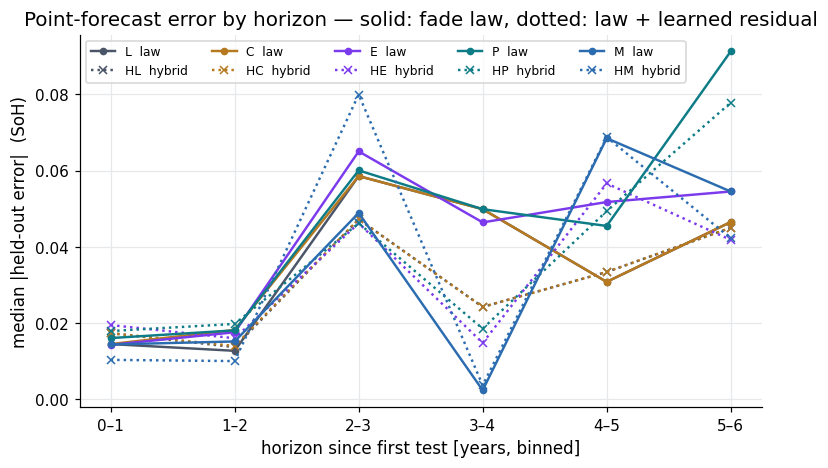

saved fig/08_fig1a_error_by_horizon.png


In [6]:
# Figure 1 — held-out error by horizon: law solid, hybrid dotted, one colour per law
LAWS = [m for m in MODELS if MODELS[m] not in ("pool", "H")]
LAW_COLOR = {"L": SLATE, "C": AMBER, "E": "#7C3AED", "P": TEAL, "M": "#2B6CB0"}
edges = np.arange(0, np.ceil(R.horizon.max()) + 1)
def binned_median_error(g):
    e = np.abs(g.soh_obs - g.pred); b = np.clip(np.digitize(g.horizon, edges) - 1, 0, len(edges) - 2)
    return pd.Series(e).groupby(b).median().reindex(range(len(edges) - 1))
fig, ax = plt.subplots(figsize=(8, 4.4))
mid = (edges[:-1] + edges[1:]) / 2
for bl in LAWS:
    k = bl[:1]; hl = next(h for h, b in HYBRID_OF.items() if b == bl)
    ax.plot(mid, binned_median_error(R[R.model == bl]), "-o", color=LAW_COLOR[k], ms=4, lw=1.6, label=f"{k}  law")
    ax.plot(mid, binned_median_error(R[R.model == hl]), ":x", color=LAW_COLOR[k], ms=5, lw=1.6, label=f"H{k}  hybrid")
ax.set_xlabel("horizon since first test [years, binned]"); ax.set_ylabel("median |held-out error|  (SoH)")
ax.set_xticks(mid); ax.set_xticklabels([f"{int(a)}–{int(b)}" for a, b in zip(edges[:-1], edges[1:])])
despine(ax); ax.legend(ncol=5, fontsize=8, loc="upper left")
put(ax, "Point-forecast error by horizon — solid: fade law, dotted: law + learned residual")
save(fig, "08_fig1a_error_by_horizon")

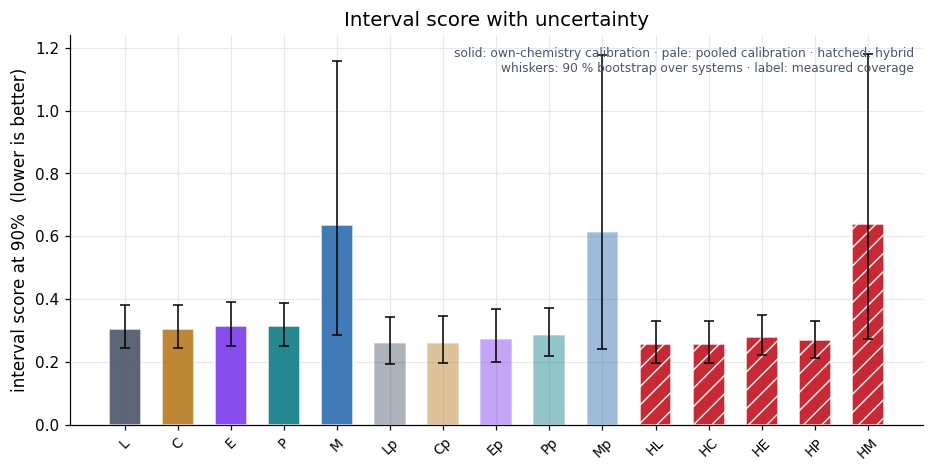

saved fig/08_fig1b_interval_score_bootstrap.png


In [7]:
# Figure 2 — interval score at 90 % with a bootstrap band over SYSTEMS (tests within a system are not independent)
rng = np.random.default_rng(0); B = 2000
systems = R.system.unique(); by_sys = {m: {s: g for s, g in gm.groupby("system")} for m, gm in R.groupby("model")}
def score_of(frames):
    d = pd.concat(frames); y, lo, hi = d.soh_obs.to_numpy(), (d.pred - d.hw).to_numpy(), (d.pred + d.hw).to_numpy()
    return interval_score(y, lo, hi, level=LEVEL)
boot = {}
for m in S.index:
    draws = np.empty(B)
    for i in range(B):
        pick = rng.choice(systems, size=len(systems), replace=True)
        draws[i] = score_of([by_sys[m][s] for s in pick if s in by_sys[m]])
    boot[m] = (np.percentile(draws, 5), np.percentile(draws, 95))
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(S)); cols = [LAW_COLOR.get(m.split()[0][0], RED) for m in S.index]
lo = np.array([boot[m][0] for m in S.index]); hi = np.array([boot[m][1] for m in S.index])

for i, m in enumerate(S.index):
    ax.bar(i, S.interval_score[m], 0.6, color=cols[i], alpha=0.45 if "pooled" in m else 0.9,
           hatch="//" if m.startswith("H") else "", edgecolor="white")

ax.errorbar(x, S.interval_score, yerr=[S.interval_score - lo, hi - S.interval_score], fmt="none", ecolor="black", capsize=3, lw=1)
ax.set_xticks(x); ax.set_xticklabels([m.split()[0] for m in S.index], rotation=45, fontsize=9)
ax.set_ylabel(f"interval score at {LEVEL:.0%}  (lower is better)"); despine(ax)
ax.text(0.99, 0.97, "solid: own-chemistry calibration · pale: pooled calibration · hatched: hybrid\nwhiskers: 90 % bootstrap over systems · label: measured coverage",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=SLATE)
put(ax, "Interval score with uncertainty")
save(fig, "08_fig1b_interval_score_bootstrap")

## 3 · Year twelve

Every model is refused a band at twelve years by the same `Envelope`, for the same reason as in
notebook 07: no field test exists there. What a fitted law can do is print what its *structure*
says — labelled as an extrapolation with no coverage attached, and carried in the manifest as
such. That is the most any model can offer beyond the last measurement, and a report that
presents it as an interval is wrong whatever the model.

In [8]:
from otwin import TwinManifest
from otwin.interfaces.manifest import Provenance
from otwin.advise import Envelope
from datetime import datetime, timezone

h_max = int(np.ceil(R.horizon.max())); age_lo, age_hi = float(tests.age_yr.min()), float(tests.age_yr.max())
P = S.loc["P  calendar + cycle"]; cov_P = float(P.picp)
Z_P = {c: float(R[(R.model.str.startswith("P")) & (R.chem == c)].z.median()) for c in tests.chem.unique()}
COEF_P = {c: fit(tests, c, "P", Z_P[c]) for c in tests.chem.unique()}
manifest = TwinManifest(
    name="fleet_fade_law_calendar_cycle_rwth", model_class="empirical_law", model_kind="calendar_sqrt_plus_cycle_throughput",
    n_states=2, n_inputs=1,
    provenance=Provenance(created=datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"), otwin_version=otwin.__version__,
                          data_source="Figgener et al. 2024, Source Data Fig. 2 (doi:10.5281/zenodo.12091223)", notes=f"MODE={MODE}"),
    parameters={**{f"a_{c}": float(COEF_P[c][0]) for c in COEF_P}, **{f"b_{c}": float(COEF_P[c][1]) for c in COEF_P}, **{f"z_{c}": Z_P[c] for c in Z_P}},
    estimated=tuple(f"{p}_{c}" for c in COEF_P for p in ("a","b","z")),
    validation=TwinManifest.validated_by("leave_one_system_out_nested", leakage_free=True, n_systems=int(R.system.nunique()), horizon_years=h_max),
    calibration=TwinManifest.calibrated_by("split_conformal_cross_system_nested", empirical_coverage=cov_P, level=LEVEL,
                                           mean_half_width=float(R[R.model.str.startswith("P")].hw.mean())),
    extra={"chemistries": sorted(tests.chem.unique()), "verdict_vs_linear": verdict})
env = Envelope(state_bounds=[(age_lo, age_hi), (0.75, 1.05)], max_horizon=h_max)

def ask(label, age, soh, horizon, chem, efc_per_yr):
    v = env.check(state=[age, soh], horizon=horizon, manifest=manifest, wants_interval=True)
    ok = bool(v) and chem in manifest.extra["chemistries"]
    print(f"{label:<46} -> {'ANSWER' if ok else 'REFUSE (band)'}")
    for b in ([] if v else v.breaches): print(f"{'':<49}{b}")
    if chem not in manifest.extra["chemistries"]: print(f"{'':<49}chemistry: '{chem}' not in calibration fleet"); return "REFUSE"
    if not ok:
        # what the structure says, labelled as such: no coverage attaches to this number
        a, b, z = COEF_P[chem][0], COEF_P[chem][1], Z_P[chem]
        t = age + horizon; fade = a*(t**z - age**z) + b*efc_per_yr*horizon
        print(f"{'':<49}extrapolation_of_law: SoH {soh - fade:.3f} at year {t:.0f} "
              f"(z={z:.2f}, {efc_per_yr:.0f} EFC/yr) — NO measured coverage; structure only")
        return "REFUSE+EXTRAPOLATION"
    return "ANSWER"

v1 = ask("year-2 LFP system, +3 years, 200 EFC/yr", 2.0, 0.95, 3, "MLFP", 200)
v2 = ask("year-1 NMC system, +11 years, 200 EFC/yr", 1.0, 0.98, 11, "MNMC", 200)
v3 = ask("year-2 NCA system, +3 years", 2.0, 0.95, 3, "NCA", 200)


year-2 LFP system, +3 years, 200 EFC/yr        -> ANSWER
year-1 NMC system, +11 years, 200 EFC/yr       -> REFUSE (band)
                                                 horizon: beyond the validated forecast horizon (asked for 11, validated to 6)
                                                 extrapolation_of_law: SoH 0.721 at year 12 (z=1.00, 200 EFC/yr) — NO measured coverage; structure only
year-2 NCA system, +3 years                    -> REFUSE (band)
                                                 chemistry: 'NCA' not in calibration fleet


## 4 · Change one thing

- **Drop the control.** Delete the pooled rows and compare hybrids to own-calibration laws only:
  "5 of 5 narrow" — the result that looked like a win before the confound was found.
- **Coarser exponents.** Set `Z_GRID = [1.0]` — no calendar structure at all. C and P collapse
  onto L; does anything change?
- **More systems, fewer tests.** Duplicate each system with jittered ages and rerun the
  bootstrap. The whiskers shrink; the bars do not move. Sample size is the lever.

## What you learned

- Set the criterion before the data. Then the table is a verdict, not an argument.
- A two-term law that fits three points is not physics; it is a runaway waiting for a horizon.
- The calibration-count confound is worth 15 %; a hybrid is worth 1–5 % on top. Control for it.
- "Inside the bootstrap band" is a result. Report the direction, the size, and the power.

This closes the course. The library gave you a model that obeys physics (01, 02), a forecast
scored against the hardest baseline (03), a band whose coverage is measured (04), a state that
respects constraints (05), a twin that refuses (06), and the same protocol on real field data
(07, 08). What it did not give you is a model that beats a straight line on sixty points — and
it told you so.

---
*For CI, not for you.*

In [9]:
HEAD = {"mode": MODE, "systems": int(R.system.nunique()), "held_out_tests": int(R.groupby("model").size().iloc[0]),
        "verdict_physics_vs_linear": verdict, "hybrid_summary": verdict_H,
        "hybrid_verdicts": {k: v for k, v in VERD.items()}, "n_common_tests": int(len(common)), "verdicts": [v1, v2, v3]}
for m in S.index:
    k = m.split()[0]; HEAD[f"picp_{k}"] = float(S.picp[m]); HEAD[f"mpiw_{k}"] = float(S.mpiw[m]); HEAD[f"interval_score_{k}"] = float(S.interval_score[m])
json.dump(HEAD, open("results_08_rwth_laws_and_hybrid.json", "w"), indent=2)
for k, v in HEAD.items(): print(f"{k:<32}{(f'{v:.4f}' if isinstance(v, float) else str(v)):>24}")
_bad = []
chk = lambda name, ok: None if ok else _bad.append(name)
chk("manifest validated", manifest.is_validated)
chk("inside-range answered", v1 == "ANSWER")
chk("beyond-horizon refused as band, reported as extrapolation", v2 == "REFUSE+EXTRAPOLATION")
chk("unseen chemistry refused", v3 == "REFUSE")
chk("all models scored on the same held-out tests", R.groupby("model").size().nunique() == 1)
chk("pooled-calibration control present for every law", all(pl in S.index for pl in POOLED_OF))
chk("hybrids never predict healthier than the anchor", bool((RH.pred <= RH.anchor + 1e-9).all()) if len(RH) else True)
chk("NNLS coefficients non-negative", all((np.asarray(c) >= 0).all() for c in COEF_P.values()))
assert not _bad, f"regression test failed: {_bad}"
print("\nregression test passed" + ("  [DEMO — proves the pipeline, not the claim]" if MODE == "DEMO" else ""))


mode                                                REAL
systems                                               16
held_out_tests                                        37
verdict_physics_vs_linear                       DOES NOT
hybrid_summary                  vs own-chemistry calibration the hybrid narrowed 4/5 laws; vs the pooled-calibration CONTROL (same residual count as the learner) it narrowed 3/5; point-forecast RMSE improved on 4/5
hybrid_verdicts                 {'L  linear fleet rate (nb 07)': {'hybrid_vs_own': True, 'hybrid_vs_pooled': True, 'hybrid_vs_L': True, 'rmse_law': 0.052530519776502464, 'rmse_hybrid': 0.049763338278118296, 'score_own': 0.3051511412758308, 'score_pooled': 0.2595419308138911, 'score_hybrid': 0.25743797073078195}, 'C  calendar only': {'hybrid_vs_own': True, 'hybrid_vs_pooled': True, 'hybrid_vs_L': True, 'rmse_law': 0.05340049387095912, 'rmse_hybrid': 0.0499170384582508, 'score_own': 0.30483745568074083, 'score_pooled': 0.2607106119703266, 'score_hybrid'